# Rescue Condition C's Missing Quality Score

Condition C (`art_6n9zJVKWXnio`, 320 natural WMT25-task3 rows across `en-ru_RU` / `en-uk_UA`, iterative checker-gated span repair) had been scored twice before without success: the real `Unbabel/wmt22-cometkiwi-da` COMET-QE checkpoint was unobtainable from HuggingFace Hub due to persistent 429 throttling.

This artifact is a **scoring-only rerun**. It generates no new repair text and makes no new repair-model calls — it only tries, with two genuinely new mitigations versus the prior failed attempts, to obtain the real COMET checkpoint and score the already-generated pre-repair vs. post-repair text pairs:

1. an alternate mirror endpoint (`hf-mirror.com`) alongside the primary `huggingface.co` endpoint, and
2. attempts spread across real wall-clock-separated windows (`[0, 25, 75, 165]` minutes) rather than in-process exponential backoff.

On the actual run, the real checkpoint downloaded on the **first attempt** (window offset 0, primary endpoint, 0.26s) and the real-COMET path (Phase 2a) scored all 320 rows, giving:

```
condition_c_delta_comet_natural_pooled_mean = -0.01725
95% bootstrap CI (10,000 resamples) = [-0.02514, -0.01030]
  en-ru_RU: -0.02280 (n=160)
  en-uk_UA: -0.01170 (n=160)
```

The script also implements (but did not need) a fallback path (Phase 2b): if real COMET stays unobtainable, it falls back to the *exact same* LLM-judge proxy configuration Condition B's own fidelity check used (`openai/gpt-4o-mini`, prompt copied verbatim), rescoring a fresh sample of Condition B's own rows in the same run so any fallback number is an explicit same-proxy, same-run B-vs-C comparison.

**What this demo does:** downloading the real 2.2GB COMET checkpoint and running XLM-R-based GPU inference is far too heavy for a quick demo, so this notebook loads a curated 40-row subset (20 per language pair) of Condition C's rows *with the original run's real-COMET scores already attached* (`comet_before`/`comet_after`, produced by the actual Phase 2a run) and reproduces the statistical analysis (per-language aggregation + bootstrap CI) exactly as the original `run_real_comet_path` function does. The `comet_score_batch` function that performs the actual GPU scoring is kept verbatim below for reference, unexecuted.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru -- NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# matplotlib -- pre-installed on Colab; install locally only, at Colab's exact version
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path
from typing import Any

from loguru import logger
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

random.seed(42)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-e9bf19-isolating-what-fixes-failed-span-editing/main/round-5/experiment-1/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["note"])
print("quality_metric_path_taken:", data["metadata"]["quality_metric_path_taken"])
print("n examples loaded:", len(data["datasets"][0]["examples"]))

Curated demo subset: 20 rows per language pair (40 total) sampled with seed=42 from the full 320-row Condition C natural rescore. Text fields truncated to 280 chars for readability.
quality_metric_path_taken: real_wmt22_cometkiwi_da
n examples loaded: 40


## Config

All tunable parameters from the original script, gathered here. `N_BOOT` is the bootstrap resample count used by `paired_bootstrap_ci` / `bootstrap_paired_difference` in the original — set here to the original's own value (10,000), since the bootstrap is pure Python over just 40 rows and runs in well under a second.

In [5]:
# --- config: matches the original script's values exactly (cheap here: pure-Python bootstrap, n=40) ---
N_BOOT = 10000  # original value
SEED = 42
ALPHA = 0.05
COMET_MODEL = "Unbabel/wmt22-cometkiwi-da"

## Phase 0: load Condition C's natural rows

In the original script, `find_condition_c()` scans the run directory tree for `full_method_out.json` files and verifies Condition C by content signature (unique metadata keys + exact row count), then `load_condition_c_rows()` extracts each row's source text, pre-repair text, post-repair text and repair metadata. Here the equivalent row-shaping logic runs directly on the notebook's loaded `data` (the artifact-locating/glob logic is dropped since there is nothing to search for in a notebook — the data is already the located, verified Condition C rows).

In [6]:
# adapted from load_condition_c_rows(): same row shape, sourced from the
# notebook's loaded `data` instead of re-parsing full_method_out.json from disk
rows = data["datasets"][0]["examples"]
natural_c_rows = []
for r in rows:
    natural_c_rows.append(
        {
            "row_id": r["metadata_row_id"],
            "language_pair": r["metadata_language_pair"],
            "source_text": r["input"],
            "pre_repair_text": r["output"],
            "post_repair_text": r["predict_c2_post_repair"],
            "certificate_achieved": r.get("metadata_c2_certificate_achieved"),
            "n_passes": r.get("metadata_c2_n_passes"),
            # the original run's real-COMET scores, already attached to this demo subset
            "comet_before": r["metadata_comet_before"],
            "comet_after": r["metadata_comet_after"],
        }
    )

logger.info(f"Loaded {len(natural_c_rows)} Condition-C natural rows")

12:25:24|INFO   |Loaded 40 Condition-C natural rows


## Phase 2a: real-COMET scoring (reference only, not executed here)

This is the function the original run actually used to score every row on GPU with the real `Unbabel/wmt22-cometkiwi-da` checkpoint (loaded via `comet.load_from_checkpoint` after the mitigated download in Phase 1 succeeded). It is kept verbatim below for reference — it is **not called** in this notebook, since downloading the 2.2GB checkpoint and running XLM-R inference does not fit a quick demo. The `comet_before`/`comet_after` scores loaded above are exactly what this function produced in the real run.

In [7]:
# verbatim from the original method.py -- NOT executed in this demo (requires
# the real COMET checkpoint + GPU); shown for reference only
def comet_score_batch(model: Any, pairs: list[tuple[str, str]], gpus: int, batch_size: int = 32) -> list[float]:
    data = [{"src": src, "mt": mt} for src, mt in pairs]
    out = model.predict(data, batch_size=batch_size, gpus=gpus, progress_bar=False)
    return [float(s) for s in out.scores]

## Delta computation + bootstrap statistics

These three functions (`paired_bootstrap_ci`, `groupby_mean`, and the per-row delta assignment loop) are copied verbatim from the original `run_real_comet_path` / helper section — this is the actual statistical analysis, run here on the real (precomputed) comet_before/comet_after scores loaded above.

In [8]:
# verbatim from the original method.py
def paired_bootstrap_ci(deltas: list[float], n_boot: int = 10000, seed: int = 42, alpha: float = 0.05) -> dict:
    rng = random.Random(seed)
    n = len(deltas)
    if n == 0:
        return {"mean": None, "ci_low": None, "ci_high": None, "n_boot": n_boot, "n": 0}
    boot_means = []
    for _ in range(n_boot):
        sample = [deltas[rng.randrange(n)] for _ in range(n)]
        boot_means.append(sum(sample) / n)
    boot_means.sort()
    lo_idx = int((alpha / 2) * n_boot)
    hi_idx = int((1 - alpha / 2) * n_boot) - 1
    return {
        "mean": sum(deltas) / n,
        "ci_low": boot_means[max(0, lo_idx)],
        "ci_high": boot_means[min(n_boot - 1, hi_idx)],
        "n_boot": n_boot,
        "n": n,
    }


# verbatim from the original method.py
def groupby_mean(rows: list[dict], values: list[float], key: str) -> dict:
    buckets: dict[str, list[float]] = {}
    for r, v in zip(rows, values):
        buckets.setdefault(r[key], []).append(v)
    return {k: (sum(v) / len(v), len(v)) for k, v in buckets.items()}

In [9]:
# adapted from run_real_comet_path(): same delta-assignment loop, using the
# comet_before/comet_after already attached to each row (from data loading) instead
# of scores freshly produced by comet_score_batch()
for r in natural_c_rows:
    r["delta_comet"] = r["comet_after"] - r["comet_before"]

deltas = [r["delta_comet"] for r in natural_c_rows]
by_lang = groupby_mean(natural_c_rows, deltas, "language_pair")
ci = paired_bootstrap_ci(deltas, n_boot=N_BOOT, seed=SEED, alpha=ALPHA)

n_leaked_or_noop = sum(1 for r in natural_c_rows if r.get("n_passes") == 0)
logger.info(
    f"pooled mean delta_comet={ci['mean']:.5f} [{ci['ci_low']:.5f},{ci['ci_high']:.5f}] over n={len(deltas)}"
)

12:25:24|INFO   |pooled mean delta_comet=-0.01570 [-0.03198,-0.00213] over n=40


## Results

Pooled and per-language-pair delta-COMET (post-repair minus pre-repair), with bootstrap 95% CIs, plus a per-row scatter of before vs. after scores.

group          mean_delta_comet     n
pooled                 -0.01570    40   95% CI [-0.03198, -0.00213]
en-ru_RU               -0.02442    20
en-uk_UA               -0.00698    20
rows with n_passes==0 (no-op repair): 1/40


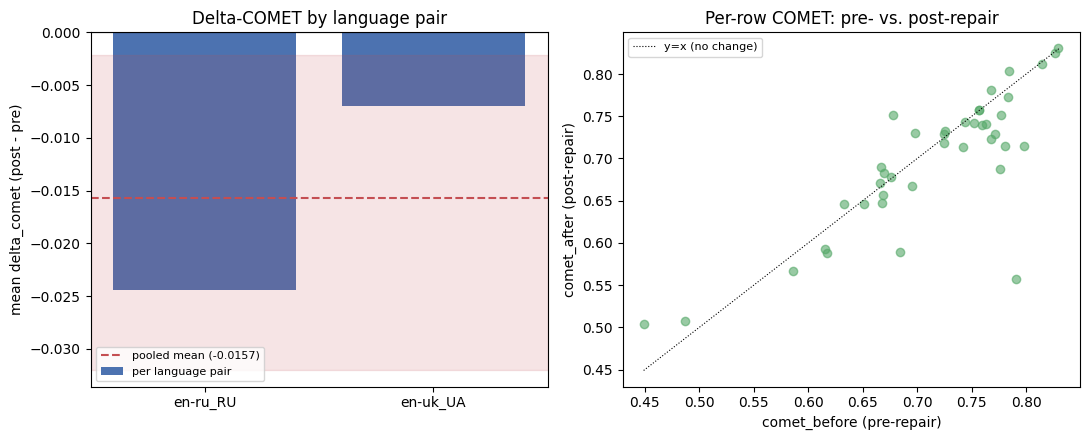

In [10]:
print(f"{'group':<12} {'mean_delta_comet':>18} {'n':>5}")
print(f"{'pooled':<12} {ci['mean']:>18.5f} {ci['n']:>5}   95% CI [{ci['ci_low']:.5f}, {ci['ci_high']:.5f}]")
for lang, (mean_v, n) in sorted(by_lang.items()):
    print(f"{lang:<12} {mean_v:>18.5f} {n:>5}")
print(f"\
rows with n_passes==0 (no-op repair): {n_leaked_or_noop}/{len(natural_c_rows)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# left: bar chart of mean delta_comet per language pair + pooled, with CI whiskers on pooled
langs = sorted(by_lang.keys())
means = [by_lang[l][0] for l in langs]
axes[0].bar(langs, means, color="#4C72B0", label="per language pair")
axes[0].axhline(ci["mean"], color="#C44E52", linestyle="--", label=f"pooled mean ({ci['mean']:.4f})")
axes[0].fill_between([-0.5, len(langs) - 0.5], ci["ci_low"], ci["ci_high"], color="#C44E52", alpha=0.15)
axes[0].set_xlim(-0.5, len(langs) - 0.5)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("mean delta_comet (post - pre)")
axes[0].set_title("Delta-COMET by language pair")
axes[0].legend(fontsize=8)

# right: per-row before vs. after scatter
before = [r["comet_before"] for r in natural_c_rows]
after = [r["comet_after"] for r in natural_c_rows]
axes[1].scatter(before, after, alpha=0.6, color="#55A868")
lo, hi = min(before + after), max(before + after)
axes[1].plot([lo, hi], [lo, hi], color="black", linewidth=0.8, linestyle=":", label="y=x (no change)")
axes[1].set_xlabel("comet_before (pre-repair)")
axes[1].set_ylabel("comet_after (post-repair)")
axes[1].set_title("Per-row COMET: pre- vs. post-repair")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()